In [10]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
import glob
from PIL import Image
import random
import shutil
from tqdm import tqdm
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenetv2_preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras.backend as K

# For GradCAM
from tensorflow.keras.models import Model
import matplotlib.cm as cm

# --- Configuration ---
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 4
CLASS_NAMES = ['Normal', 'Hemorrhagic', 'Ischemic', 'Others']
TARGET_ACCURACY = 0.99
SEED = 42

# Dataset paths - UPDATE THESE TO YOUR ACTUAL PATHS
ORIGINAL_DATASET_PATH = "/kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset"
NEW_DATASET_PATH = "/kaggle/input/others/Others"

# --- 1. Setup and Seeding ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seeds set to {seed} for reproducibility")

set_seed(SEED)

# --- 2. Dataset Processing Functions ---
def analyze_others_dataset(others_path):
    """Analyze the Others dataset structure and classify by type."""
    print(f"\n=== Analyzing Others Dataset at {others_path} ===")
    
    if not os.path.exists(others_path):
        print(f"ERROR: Others dataset path not found: {others_path}")
        print("Please check if the path is correct and the dataset is uploaded.")
        return {}
    
    # Get all image files
    image_extensions = ['*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG', '*.JPEG']
    all_files = []
    
    for ext in image_extensions:
        files = glob.glob(os.path.join(others_path, '**', ext), recursive=True)
        all_files.extend(files)
        print(f"Found {len(files)} files with extension {ext}")
    
    print(f"Total files found in Others dataset: {len(all_files)}")
    
    if len(all_files) == 0:
        print("WARNING: No image files found in Others dataset!")
        return {}
    
    # Classify files based on filename patterns
    classification = {
        'epidural': [],
        'subdural': [],
        'subgaleal': [],
        'meningioma': [],
        'unclassified': []
    }
    
    for file_path in all_files:
        filename = os.path.basename(file_path).lower()
        
        if 'epidural' in filename or 'edh' in filename:
            classification['epidural'].append(file_path)
        elif 'subdural' in filename or 'sdh' in filename:
            classification['subdural'].append(file_path)
        elif 'subgaleal' in filename or 'sgh' in filename:
            classification['subgaleal'].append(file_path)
        elif 'meningioma' in filename or 'meningiom' in filename:
            classification['meningioma'].append(file_path)
        else:
            classification['unclassified'].append(file_path)
    
    # Print classification results
    print("Classification results:")
    for category, files in classification.items():
        print(f"- {category.capitalize()}: {len(files)} images")
    
    return classification

def create_others_dataset_structure(classification, output_dir="processed_others"):
    """Create organized structure for Others dataset."""
    print(f"\n=== Creating Others Dataset Structure in {output_dir} ===")
    
    if not classification:
        print("WARNING: No classification data provided. Skipping Others dataset processing.")
        return [], []
    
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir)
    
    others_paths = []
    others_labels = []
    
    for category, file_list in classification.items():
        if not file_list:
            continue
            
        category_dir = os.path.join(output_dir, category)
        os.makedirs(category_dir, exist_ok=True)
        
        print(f"Processing {len(file_list)} files for category: {category}")
        
        for i, src_path in enumerate(tqdm(file_list, desc=f"Processing {category}")):
            try:
                # Load and validate image
                img = Image.open(src_path)
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Save with standardized name
                dst_filename = f"{category}_{i:04d}.png"
                dst_path = os.path.join(category_dir, dst_filename)
                img.save(dst_path, 'PNG')
                
                others_paths.append(dst_path)
                others_labels.append(3)  # All Others class = 3
                
            except Exception as e:
                print(f"Error processing {src_path}: {e}")
    
    print(f"Successfully processed {len(others_paths)} images for Others class")
    return others_paths, others_labels

def load_original_dataset(root_dir):
    """Load original 3-class dataset."""
    print(f"\n=== Loading Original Dataset from {root_dir} ===")
    
    if not os.path.exists(root_dir):
        print(f"ERROR: Original dataset path not found: {root_dir}")
        print("Please check if the path is correct and the dataset is uploaded.")
        return [], []
    
    image_paths = []
    labels = []
    class_map = {
        'Normal': 0,
        'Bleeding': 1,  # Hemorrhagic
        'Ischemia': 2
    }
    
    print("Looking for class folders...")
    for class_folder_name, label_idx in class_map.items():
        # Try different possible paths
        possible_paths = [
            os.path.join(root_dir, class_folder_name, "PNG"),
            os.path.join(root_dir, class_folder_name),
            os.path.join(root_dir, class_folder_name.lower()),
            os.path.join(root_dir, class_folder_name.upper())
        ]
        
        current_class_path = None
        for path in possible_paths:
            if os.path.exists(path) and os.listdir(path):
                current_class_path = path
                break
        
        if current_class_path:
            png_files = glob.glob(os.path.join(current_class_path, '*.png'))
            jpg_files = glob.glob(os.path.join(current_class_path, '*.jpg'))
            jpeg_files = glob.glob(os.path.join(current_class_path, '*.jpeg'))
            all_files = png_files + jpg_files + jpeg_files
            
            for img_path in all_files:
                image_paths.append(img_path)
                labels.append(label_idx)
            print(f"Found {len(all_files)} images for {CLASS_NAMES[label_idx]} at {current_class_path}")
        else:
            print(f"WARNING: No images found for class {class_folder_name}")
    
    print(f"Total original dataset images: {len(image_paths)}")
    return image_paths, labels

def create_balanced_dataset(all_paths, all_labels, min_samples_per_class=500):
    """Create a balanced dataset through augmentation if needed."""
    print("\n=== Creating Balanced Dataset ===")
    
    if not all_paths or not all_labels:
        print("ERROR: No data provided for balancing!")
        return [], []
    
    # Count samples per class
    unique_labels, counts = np.unique(all_labels, return_counts=True)
    class_distribution = dict(zip(unique_labels, counts))
    
    print("Original class distribution:")
    for label, count in class_distribution.items():
        if label < len(CLASS_NAMES):
            print(f"  {CLASS_NAMES[label]}: {count}")
    
    # Find target count (max of min_samples_per_class or max existing class)
    target_count = max(min_samples_per_class, max(counts) if counts.size > 0 else min_samples_per_class)
    print(f"Target samples per class: {target_count}")
    
    balanced_paths = []
    balanced_labels = []
    
    for class_idx in range(NUM_CLASSES):
        class_paths = [path for path, label in zip(all_paths, all_labels) if label == class_idx]
        class_labels = [label for label in all_labels if label == class_idx]
        
        if len(class_paths) == 0:
            print(f"WARNING: No samples found for class {CLASS_NAMES[class_idx]}")
            continue
        
        # Duplicate samples to reach target count
        original_count = len(class_paths)
        while len(class_paths) < target_count:
            additional_needed = min(original_count, target_count - len(class_paths))
            indices = np.random.choice(original_count, additional_needed, replace=False)
            class_paths.extend([class_paths[i] for i in indices])
            class_labels.extend([class_labels[i] for i in indices])
        
        # Take exactly target_count samples
        class_paths = class_paths[:target_count]
        class_labels = class_labels[:target_count]
        
        balanced_paths.extend(class_paths)
        balanced_labels.extend(class_labels)
        
        print(f"Balanced {CLASS_NAMES[class_idx]}: {len(class_paths)} samples")
    
    return balanced_paths, balanced_labels

# --- 3. Advanced Data Preprocessing ---
def parse_image_advanced(filepath, label, preprocess_fn):
    """Advanced image parsing with error handling."""
    try:
        image = tf.io.read_file(filepath)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.cast(image, tf.float32)
        image = tf.image.resize(image, [IMG_WIDTH, IMG_HEIGHT])
        
        # Apply CLAHE for better contrast
        image = tf.py_function(apply_clahe, [image], tf.float32)
        image.set_shape([IMG_WIDTH, IMG_HEIGHT, 3])
        
        image = preprocess_fn(image)
        return image, label
    except Exception as e:
        print(f"Error processing image {filepath}: {e}")
        # Return a black image if loading fails
        black_image = tf.zeros([IMG_WIDTH, IMG_HEIGHT, 3], dtype=tf.float32)
        return preprocess_fn(black_image), label

def apply_clahe(image):
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)."""
    image_np = image.numpy().astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    # Apply CLAHE to each channel
    for i in range(3):
        image_np[:, :, i] = clahe.apply(image_np[:, :, i])
    
    return tf.cast(image_np, tf.float32)

def advanced_augment_image(image, label):
    """Advanced augmentation for medical images."""
    # Geometric augmentations
    image = tf.image.random_flip_left_right(image)
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    
    # Intensity augmentations (mild for medical images)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    
    # Random zoom with safe bounds checking
    if tf.random.uniform([]) > 0.5:
        # Generate zoom factor between 0.9 and 1.0 (safe range)
        zoom_factor = tf.random.uniform([], 0.9, 1.0)
        
        # Calculate crop size
        img_shape = tf.cast(tf.shape(image)[:2], tf.float32)
        crop_size = tf.cast(img_shape * zoom_factor, tf.int32)
        
        # Ensure crop dimensions don't exceed image dimensions
        crop_size = tf.minimum(crop_size, tf.shape(image)[:2])
        
        # Calculate safe offsets
        offset = (img_shape - tf.cast(crop_size, tf.float32)) / 2
        offset = tf.cast(tf.math.round(offset), tf.int32)
        
        # Perform safe crop
        image = tf.image.crop_to_bounding_box(
            image,
            offset_height=offset[0],
            offset_width=offset[1],
            target_height=crop_size[0],
            target_width=crop_size[1]
        )
        image = tf.image.resize(image, [IMG_WIDTH, IMG_HEIGHT])
    
    return image, label
    
def create_advanced_dataset(filepaths, labels, batch_size, preprocess_fn, is_training=True):
    """Create advanced dataset with better preprocessing."""
    # Check for empty inputs (works for lists and arrays)
    if len(filepaths) == 0 or len(labels) == 0:
        print("ERROR: No data provided for dataset creation!")
        return None
        
    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    
    if is_training:
        dataset = dataset.shuffle(buffer_size=len(filepaths), seed=SEED)
    
    dataset = dataset.map(
        lambda fp, lbl: parse_image_advanced(fp, lbl, preprocess_fn),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    if is_training:
        dataset = dataset.map(advanced_augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# --- 4. Advanced Model Building ---
def build_advanced_model(base_model_name, num_classes, img_width, img_height, learning_rate=1e-4):
    """Build advanced model with better architecture."""
    input_shape = (img_width, img_height, 3)
    
    if base_model_name == 'EfficientNetB0':
        base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
        preprocess_fn = efficientnet_preprocess_input
    elif base_model_name == 'MobileNetV2':
        base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
        preprocess_fn = mobilenetv2_preprocess_input
    else:
        raise ValueError("Unsupported base_model_name")
    
    # Fine-tuning strategy
    base_model.trainable = True
    fine_tune_at = len(base_model.layers) // 2
    
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False
    
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=True)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    
    # Custom optimizer with learning rate scheduling
    initial_learning_rate = learning_rate
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate,
        decay_steps=1000,
        decay_rate=0.9,
        staircase=True
    )
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    # Comprehensive metrics
    metrics = [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.F1Score(name='f1_score')
    ]
    
    # Add per-class metrics
    for i in range(num_classes):
        metrics.extend([
            tf.keras.metrics.Precision(class_id=i, name=f'precision_{CLASS_NAMES[i].lower()}'),
            tf.keras.metrics.Recall(class_id=i, name=f'recall_{CLASS_NAMES[i].lower()}')
        ])
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=metrics
    )
    
    return model, preprocess_fn

# --- 5. GradCAM Implementation ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generate GradCAM heatmap."""
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    """Display GradCAM visualization."""
    img = keras.preprocessing.image.load_img(img_path)
    img = keras.preprocessing.image.img_to_array(img)
    
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
    
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)
    
    return superimposed_img

# --- 6. Training with Advanced Callbacks ---
def create_advanced_callbacks(model_name, patience_factor=1.5):
    """Create advanced callbacks for training."""
    model_checkpoint_path = f'best_{model_name}_4class.keras'
    
    callbacks = [
        ModelCheckpoint(
            filepath=model_checkpoint_path,
            save_best_only=True,
            monitor='val_accuracy',
            mode='max',
            verbose=1,
            save_weights_only=False
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=int(7 * patience_factor),
            min_lr=1e-8,
            verbose=1,
            cooldown=3
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=int(15 * patience_factor),
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001
        ),
        # Custom callback to stop when target accuracy is reached
        keras.callbacks.LambdaCallback(
            on_epoch_end=lambda epoch, logs: 
                print(f"\nEpoch {epoch+1}: Val Accuracy = {logs['val_accuracy']:.4f}") 
                if logs['val_accuracy'] >= TARGET_ACCURACY 
                else None
        )
    ]
    
    return callbacks, model_checkpoint_path

# --- 7. Main Training Function ---
def train_advanced_models():
    """Main training function."""
    print("=== Starting Advanced 4-Class Brain CT Classification ===")
    
    try:
        # Step 1: Process Others dataset
        print("Step 1: Processing Others dataset...")
        others_classification = analyze_others_dataset(NEW_DATASET_PATH)
        others_paths, others_labels = create_others_dataset_structure(others_classification)
        
        # Step 2: Load original dataset
        print("Step 2: Loading original dataset...")
        original_paths, original_labels = load_original_dataset(ORIGINAL_DATASET_PATH)
        
        # Check if we have any data
        if not original_paths and not others_paths:
            print("ERROR: No data found in either dataset!")
            print("Please check your dataset paths and ensure the data is properly uploaded.")
            return None, None, None
        
        # Step 3: Combine datasets
        all_paths = original_paths + others_paths
        all_labels = original_labels + others_labels
        
        print(f"\nStep 3: Combined dataset: {len(all_paths)} images")
        print("Class distribution:")
        for i in range(NUM_CLASSES):
            count = all_labels.count(i)
            print(f"  {CLASS_NAMES[i]}: {count}")
        
        if len(all_paths) == 0:
            print("ERROR: No images found in combined dataset!")
            return None, None, None
        
        # Step 4: Create balanced dataset
        print("Step 4: Creating balanced dataset...")
        balanced_paths, balanced_labels = create_balanced_dataset(all_paths, all_labels)
        
        if not balanced_paths:
            print("ERROR: Failed to create balanced dataset!")
            return None, None, None
        
        # Step 5: Split data
        print("Step 5: Splitting data...")
        train_paths, val_paths, train_labels, val_labels = train_test_split(
            balanced_paths, balanced_labels, 
            test_size=0.2, 
            random_state=SEED, 
            stratify=balanced_labels
        )
        
        print(f"\nFinal split:")
        print(f"Training: {len(train_paths)} images")
        print(f"Validation: {len(val_paths)} images")
        
        # Convert to categorical
        train_labels_cat = to_categorical(train_labels, num_classes=NUM_CLASSES)
        val_labels_cat = to_categorical(val_labels, num_classes=NUM_CLASSES)
        
        # Step 6: Calculate class weights
        print("Step 6: Calculating class weights...")
        class_weights_calculated = class_weight.compute_class_weight(
            'balanced',
            classes=np.unique(train_labels),
            y=np.array(train_labels)
        )
        class_weights_dict = dict(enumerate(class_weights_calculated))
        print(f"Class weights: {class_weights_dict}")
        
        # Step 7: Train models
        print("Step 7: Training models...")
        models_to_train = ['EfficientNetB0', 'MobileNetV2']
        trained_models = {}
        histories = {}
        model_performances = {}
        
        for model_name in models_to_train:
            print(f"\n{'='*50}")
            print(f"Training {model_name}")
            print(f"{'='*50}")
            
            # Build model
            model, preprocess_fn = build_advanced_model(
                model_name, NUM_CLASSES, IMG_WIDTH, IMG_HEIGHT, learning_rate=1e-4
            )
            
            # Create datasets
            train_ds = create_advanced_dataset(
                train_paths, train_labels_cat, BATCH_SIZE, preprocess_fn, is_training=True
            )
            val_ds = create_advanced_dataset(
                val_paths, val_labels_cat, BATCH_SIZE, preprocess_fn, is_training=False
            )
            
            if train_ds is None or val_ds is None:
                print(f"ERROR: Failed to create datasets for {model_name}")
                continue
            
            # Create callbacks
            callbacks, model_checkpoint_path = create_advanced_callbacks(model_name)
            
            # Train model
            print(f"Starting training for {model_name}...")
            history = model.fit(
                train_ds,
                epochs=EPOCHS,
                validation_data=val_ds,
                callbacks=callbacks,
                class_weight=class_weights_dict,
                verbose=1
            )
            
            # Load best weights
            if os.path.exists(model_checkpoint_path):
                model.load_weights(model_checkpoint_path)
                print(f"Loaded best weights for {model_name}")
            
            trained_models[model_name] = model
            histories[model_name] = history
            
            # Evaluate
            val_results = model.evaluate(val_ds, verbose=0)
            val_accuracy = val_results[1]  # accuracy is typically the second metric
            
            print(f"\n{model_name} Final Validation Accuracy: {val_accuracy:.4f}")
            model_performances[model_name] = val_accuracy
            
            # Generate predictions for detailed evaluation
            y_pred_probs = model.predict(val_ds, verbose=0)
            y_pred_classes = np.argmax(y_pred_probs, axis=1)
            y_true_classes = val_labels
            
            print(f"\nClassification Report for {model_name}:")
            print(classification_report(y_true_classes, y_pred_classes, 
                                      target_names=CLASS_NAMES, zero_division=0))
            
            # Confusion Matrix
            cm = confusion_matrix(y_true_classes, y_pred_classes)
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                       xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
            plt.title(f'Confusion Matrix - {model_name}')
            plt.xlabel('Predicted')
            plt.ylabel('True')
            plt.tight_layout()
            plt.savefig(f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
            plt.show()
        
        if not trained_models:
            print("ERROR: No models were successfully trained!")
            return None, None, None
        
        # Step 8: Select best model and save
        best_model_name = max(model_performances, key=model_performances.get)
        best_accuracy = model_performances[best_model_name]
        
        print(f"\n{'='*50}")
        print(f"BEST MODEL: {best_model_name}")
        print(f"ACCURACY: {best_accuracy:.4f}")
        print(f"{'='*50}")
        
        best_model = trained_models[best_model_name]
        
        # Save the best model
        final_model_path = 'New_brain_Model.keras'
        best_model.save(final_model_path)
        print(f"Best model saved to: {final_model_path}")
        
        # Save model info
        model_info = {
            'model_name': best_model_name,
            'accuracy': float(best_accuracy),
            'class_names': CLASS_NAMES,
            'input_shape': (IMG_WIDTH, IMG_HEIGHT, 3),
            'num_classes': NUM_CLASSES
        }
        
        import json
        with open('model_info.json', 'w') as f:
            json.dump(model_info, f, indent=2)
        
        # Step 9: Visualize training history
        plot_training_history(histories)
        
        # Step 10: Generate GradCAM examples
        if len(val_paths) >= 5:
            generate_gradcam_examples(best_model, val_paths[:5], val_labels[:5], best_model_name)
        
        return best_model, best_model_name, model_performances
        
    except Exception as e:
        print(f"ERROR in main training function: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None

def plot_training_history(histories):
    """Plot training history for all models."""
    if not histories:
        print("No training histories to plot.")
        return
        
    fig, axes = plt.subplots(2, len(histories), figsize=(15, 10))
    if len(histories) == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, (model_name, history) in enumerate(histories.items()):
        # Accuracy plot
        axes[0, idx].plot(history.history['accuracy'], label='Train Accuracy')
        axes[0, idx].plot(history.history['val_accuracy'], label='Val Accuracy')
        axes[0, idx].axhline(y=TARGET_ACCURACY, color='r', linestyle='--', 
                           label=f'Target ({TARGET_ACCURACY})')
        axes[0, idx].set_title(f'{model_name} - Accuracy')
        axes[0, idx].set_xlabel('Epoch')
        axes[0, idx].set_ylabel('Accuracy')
        axes[0, idx].legend()
        axes[0, idx].grid(True)
        
        # Loss plot
        axes[1, idx].plot(history.history['loss'], label='Train Loss')
        axes[1, idx].plot(history.history['val_loss'], label='Val Loss')
        axes[1, idx].set_title(f'{model_name} - Loss')
        axes[1, idx].set_xlabel('Epoch')
        axes[1, idx].set_ylabel('Loss')
        axes[1, idx].legend()
        axes[1, idx].grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

def generate_gradcam_examples(model, sample_paths, sample_labels, model_name):
    """Generate GradCAM examples."""
    print("\n=== Generating GradCAM Examples ===")
    
    # Find the last convolutional layer
    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if len(layer.output_shape) == 4:  # Conv layer has 4D output
            last_conv_layer_name = layer.name
            break
    
    if last_conv_layer_name is None:
        print("No convolutional layer found for GradCAM")
        return
    
    print(f"Using layer: {last_conv_layer_name}")
    
    # Get preprocessing function
    if model_name == 'EfficientNetB0':
        preprocess_fn = efficientnet_preprocess_input
    else:
        preprocess_fn = mobilenetv2_preprocess_input
    
    fig, axes = plt.subplots(len(sample_paths), 3, figsize=(15, 5*len(sample_paths)))
    if len(sample_paths) == 1:
        axes = axes.reshape(1, -1)
    
    for i, (img_path, true_label) in enumerate(zip(sample_paths, sample_labels)):
        try:
            # Load and preprocess image
            img = keras.preprocessing.image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
            img_array = keras.preprocessing.image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_fn(img_array)
            
            # Make prediction
            preds = model.predict(img_array, verbose=0)
            pred_class = np.argmax(preds[0])
            confidence = np.max(preds[0])
            
            # Generate GradCAM
            heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
            
            # Display original image
            axes[i, 0].imshow(img)
            axes[i, 0].set_title(f'Original\nTrue: {CLASS_NAMES[true_label]}')
            axes[i, 0].axis('off')
            
            # Display heatmap
            axes[i, 1].imshow(heatmap, cmap='jet')
            axes[i, 1].set_title('GradCAM Heatmap')
            axes[i, 1].axis('off')
            
            # Display superimposed
            superimposed = display_gradcam(img_path, heatmap)
            axes[i, 2].imshow(superimposed)
            axes[i, 2].set_title(f'Superimposed\nPred: {CLASS_NAMES[pred_class]} ({confidence:.3f})')
            axes[i, 2].axis('off')
            
        except Exception as e:
            print(f"Error generating GradCAM for {img_path}: {e}")
    
    plt.tight_layout()
    plt.savefig('gradcam_examples.png', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    print("=== Starting Script ===")
    try:
        best_model, model_name, performances = train_advanced_models()
        if best_model:
            print(f"Training completed! Best model: {model_name}")
        else:
            print("ERROR: Training failed!")
    except Exception as e:
        print(f"CRITICAL ERROR: {e}")
        import traceback
        traceback.print_exc()


Random seeds set to 42 for reproducibility
=== Starting Script ===
=== Starting Advanced 4-Class Brain CT Classification ===
Step 1: Processing Others dataset...

=== Analyzing Others Dataset at /kaggle/input/others/Others ===
Found 78 files with extension *.png
Found 196 files with extension *.jpg
Found 48 files with extension *.jpeg
Found 0 files with extension *.PNG
Found 0 files with extension *.JPG
Found 0 files with extension *.JPEG
Total files found in Others dataset: 322
Classification results:
- Epidural: 10 images
- Subdural: 160 images
- Subgaleal: 53 images
- Meningioma: 37 images
- Unclassified: 62 images

=== Creating Others Dataset Structure in processed_others ===
Processing 10 files for category: epidural


Processing epidural: 100%|██████████| 10/10 [00:00<00:00, 46.17it/s]


Processing 160 files for category: subdural


Processing subdural: 100%|██████████| 160/160 [00:11<00:00, 13.36it/s]


Processing 53 files for category: subgaleal


...

Processing meningioma: 100%|██████████| 37/37 [00:01<00:00, 25.52it/s]


Processing 62 files for category: unclassified


Processing unclassified: 100%|██████████| 62/62 [00:02<00:00, 22.13it/s]


Successfully processed 322 images for Others class
Step 2: Loading original dataset...

=== Loading Original Dataset from /kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset ===
Looking for class folders...
Found 4427 images for Normal at /kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG
Found 1093 images for Hemorrhagic at /kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Bleeding/PNG
Found 1130 images for Ischemic at /kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Ischemia/PNG
Total original dataset images: 6650

Step 3: Combined dataset: 6972 images
Class distribution:
  Normal: 4427
  Hemorrhagic: 1093
  Ischemic: 1130
  Others: 322
Step 4: Creating balanced dataset...

=== Creating Balanced Dataset ===
Original class distribution:
  Normal: 4427
  Hemorrhagic: 1093
  Ischemic: 1130
  Others: 322
Target samples per class: 4427
Balanced Normal: 4427 samples
Balanced Hemorrhagic: 4427 samples
Balanced Ischemic: 4427 samples
B

KeyboardInterrupt: 

2025-06-08 20:41:27.031056: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749415287.243761      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749415287.305497      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Random seeds set to 42 for reproducibility
=== ANALYZING DATASETS ===

Stroke Dataset structure (counts of PNG files per class):
- Ischemia: 1130 images (from /kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Ischemia/PNG)
- Bleeding: 1093 images (from /kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Bleeding/PNG)
- Normal: 4427 images (from /kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG)
- External_Test: 200 images (from /kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/External_Test/PNG)

Others Dataset structure (counts of PNG files per class):
- root: 78 images (from /kaggle/input/others/Others)

=== LOADING DATASETS ===
Loaded 4427 images for stroke class 'Normal' -> 'Normal'
Loaded 1093 images for stroke class 'Bleeding' -> 'Hemorrhagic'
Loaded 1130 images for stroke class 'Ischemia' -> 'Ischemia'
Loaded 78 images for 'Others' class

Stroke dataset: 6650 images
Others dataset: 78 images
Stroke class distribution: Norm

I0000 00:00:1749415301.054922      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749415301.055647      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


I0000 00:00:1749415364.724577      97 service.cc:148] XLA service 0x797d68004000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749415364.725895      97 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749415364.725923      97 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749415370.181062      97 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1749415378.790959      97 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749415378.930452      97 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749415379.258239      97 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. Th

  1/337 ━━━━━━━━━━━━━━━━━━━━ 8:54:17 95s/step - accuracy: 0.6250 - loss: 0.3434 - precision_others: 0.0000e+00 - precision_stroke: 1.0000 - recall_others: 0.0000e+00 - recall_stroke: 0.6250

I0000 00:00:1749415400.963563      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


336/337 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8489 - loss: 0.4028 - precision_others: 0.0595 - precision_stroke: 0.9968 - recall_others: 0.7477 - recall_stroke: 0.8500

E0000 00:00:1749415437.019958      97 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749415437.154823      97 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8490 - loss: 0.4025 - precision_others: 0.0596 - precision_stroke: 0.9968 - recall_others: 0.7480 - recall_stroke: 0.8501
Epoch 1: val_accuracy improved from -inf to 0.94651, saving model to best_EfficientNetB0_binary_temp.keras
337/337 ━━━━━━━━━━━━━━━━━━━━ 174s 234ms/step - accuracy: 0.8491 - loss: 0.4021 - precision_others: 0.0597 - precision_stroke: 0.9968 - recall_others: 0.7484 - recall_stroke: 0.8502 - val_accuracy: 0.9465 - val_loss: 0.2402 - val_precision_others: 0.1216 - val_precision_stroke: 0.9945 - val_recall_others: 0.5625 - val_recall_stroke: 0.9511 - learning_rate: 1.0000e-04
Epoch 2/50
336/337 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9573 - loss: 0.1408 - precision_others: 0.2097 - precision_stroke: 0.9995 - recall_others: 0.9556 - recall_stroke: 0.9573
Epoch 2: val_accuracy improved from 0.94651 to 0.97548, saving model to best_EfficientNetB0_binary_temp.keras
337/337 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - a

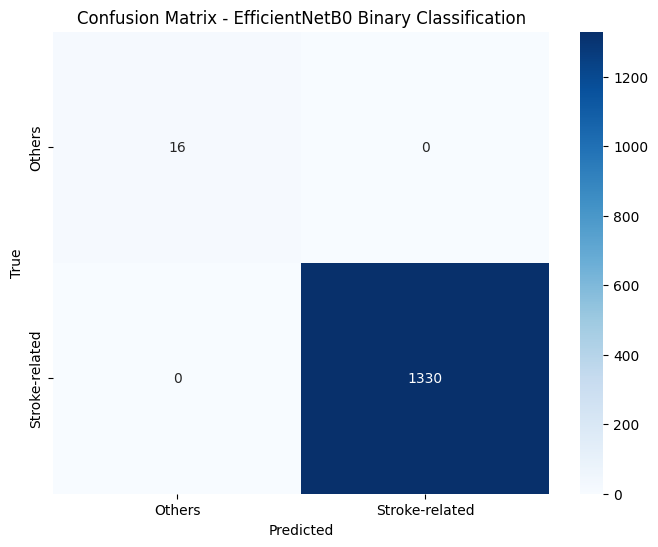


=== TRAINING MOBILENETV2 FOR BINARY CLASSIFICATION ===
Class weights: {0: 43.403225806451616, 1: 0.505827067669173}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.8871 - loss: 0.4685 - precision_others: 0.0713 - precision_stroke: 0.9965 - recall_others: 0.7077 - recall_stroke: 0.8890
Epoch 1: val_accuracy improved from -inf to 0.97994, saving model to best_MobileNetV2_binary_temp.keras
337/337 ━━━━━━━━━━━━━━━━━━━━ 113s 160ms/step - accuracy: 0.8872 - loss: 0.4680 - precision_others: 0.0714 - precision_stroke: 0.9965 - recall_others: 0.7082 - recall_stroke: 0.8890 - val_accuracy: 0.9799 - val_loss: 0.1007 - val_precision_others: 0.3103 - val_precision_stroke: 0.9947 - val_recall_others: 0.5625 - val_recall_stroke: 0.9850 - learning_rate: 1.0000e-04
Epoch 2/50
336/337 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9254 - loss: 0.2521 - precision_others: 0.1205 - precision_stroke: 0.9980 - recall_others: 0.8365 - reca

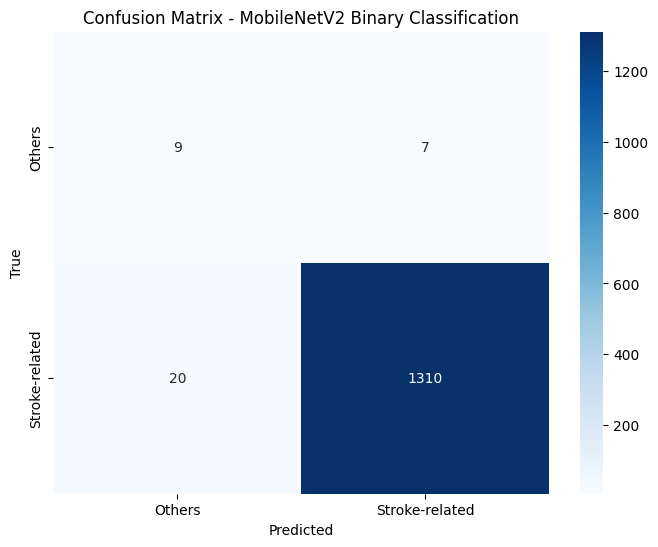


TRAINING STROKE CLASSIFIERS (NORMAL vs HEMORRHAGIC vs ISCHEMIC)

=== TRAINING EFFICIENTNETB0 FOR STROKE CLASSIFICATION ===
Class weights: {0: 0.5006587615283268, 1: 2.028985507246377, 2: 1.9616519174041298}
Epoch 1/50
332/333 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5153 - loss: 0.9482 - precision_hemorrhagic: 0.4964 - precision_ischemic: 0.3054 - precision_normal: 0.8887 - recall_hemorrhagic: 0.3682 - recall_ischemic: 0.2692 - recall_normal: 0.3383

E0000 00:00:1749416659.949245      94 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749416660.085290      94 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.5157 - loss: 0.9477 - precision_hemorrhagic: 0.4969 - precision_ischemic: 0.3057 - precision_normal: 0.8888 - recall_hemorrhagic: 0.3688 - recall_ischemic: 0.2697 - recall_normal: 0.3389
Epoch 1: val_accuracy improved from -inf to 0.58045, saving model to best_EfficientNetB0_stroke_temp.keras
333/333 ━━━━━━━━━━━━━━━━━━━━ 172s 241ms/step - accuracy: 0.5161 - loss: 0.9473 - precision_hemorrhagic: 0.4973 - precision_ischemic: 0.3060 - precision_normal: 0.8889 - recall_hemorrhagic: 0.3694 - recall_ischemic: 0.2702 - recall_normal: 0.3394 - val_accuracy: 0.5805 - val_loss: 0.7753 - val_precision_hemorrhagic: 0.9856 - val_precision_ischemic: 0.3409 - val_precision_normal: 0.9806 - val_recall_hemorrhagic: 0.6256 - val_recall_ischemic: 0.8584 - val_recall_normal: 0.3435 - learning_rate: 1.0000e-04
Epoch 2/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7955 - loss: 0.4917 - precision_hemorrhagic: 0.7818 - precision_ischemic: 0

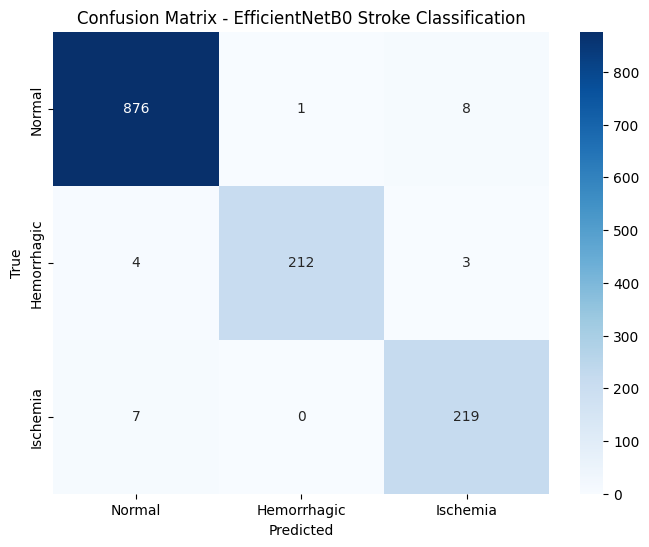


=== TRAINING MOBILENETV2 FOR STROKE CLASSIFICATION ===
Class weights: {0: 0.5006587615283268, 1: 2.028985507246377, 2: 1.9616519174041298}
Epoch 1/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5748 - loss: 0.9653 - precision_hemorrhagic: 0.4251 - precision_ischemic: 0.3326 - precision_normal: 0.8844 - recall_hemorrhagic: 0.5795 - recall_ischemic: 0.4121 - recall_normal: 0.5069
Epoch 1: val_accuracy improved from -inf to 0.72256, saving model to best_MobileNetV2_stroke_temp.keras
333/333 ━━━━━━━━━━━━━━━━━━━━ 115s 165ms/step - accuracy: 0.5751 - loss: 0.9648 - precision_hemorrhagic: 0.4255 - precision_ischemic: 0.3327 - precision_normal: 0.8845 - recall_hemorrhagic: 0.5797 - recall_ischemic: 0.4124 - recall_normal: 0.5073 - val_accuracy: 0.7226 - val_loss: 0.7922 - val_precision_hemorrhagic: 1.0000 - val_precision_ischemic: 0.3598 - val_precision_normal: 0.7887 - val_recall_hemorrhagic: 0.1963 - val_recall_ischemic: 0.3009 - val_recall_normal: 0.9446 - learning_rate: 1.000

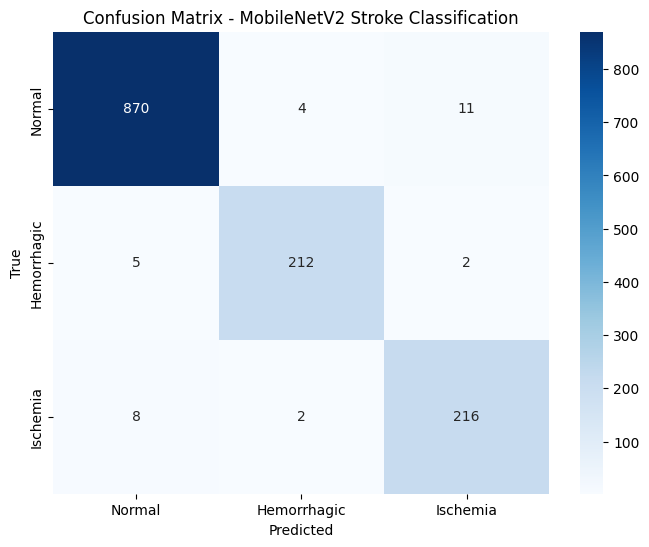


MODEL SELECTION
Best Binary Classifier: EfficientNetB0 (Accuracy: 1.0000)
Best Stroke Classifier: EfficientNetB0 (Accuracy: 0.9827)

Saved best binary classifier: best_binary_classifier.keras
Saved best stroke classifier: best_stroke_classifier.keras

TESTING HIERARCHICAL CLASSIFICATION SYSTEM
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step
Sample Hierarchical Predictions:
Image 1: True=Others, Predicted=Ischemia
Image 2: True=Others, Predicted=Normal
Image 3: True=Others, Predicted=Ischemia
Image 4: True=Others, Predicted=Hemorrhagic
Image 5: True=Others, Predicted=Normal
Image 6: True=Others, Predicted=Normal
Image 7: True=Others, Predicted=Hemorrhagic
Image 8: True=Others, Predicted=Normal
Image 9: True=Others, Predicted=Normal
Image 10: True=Others, Predicted=Normal

Hierarchical system tested on 50 images
System is ready for deployment!


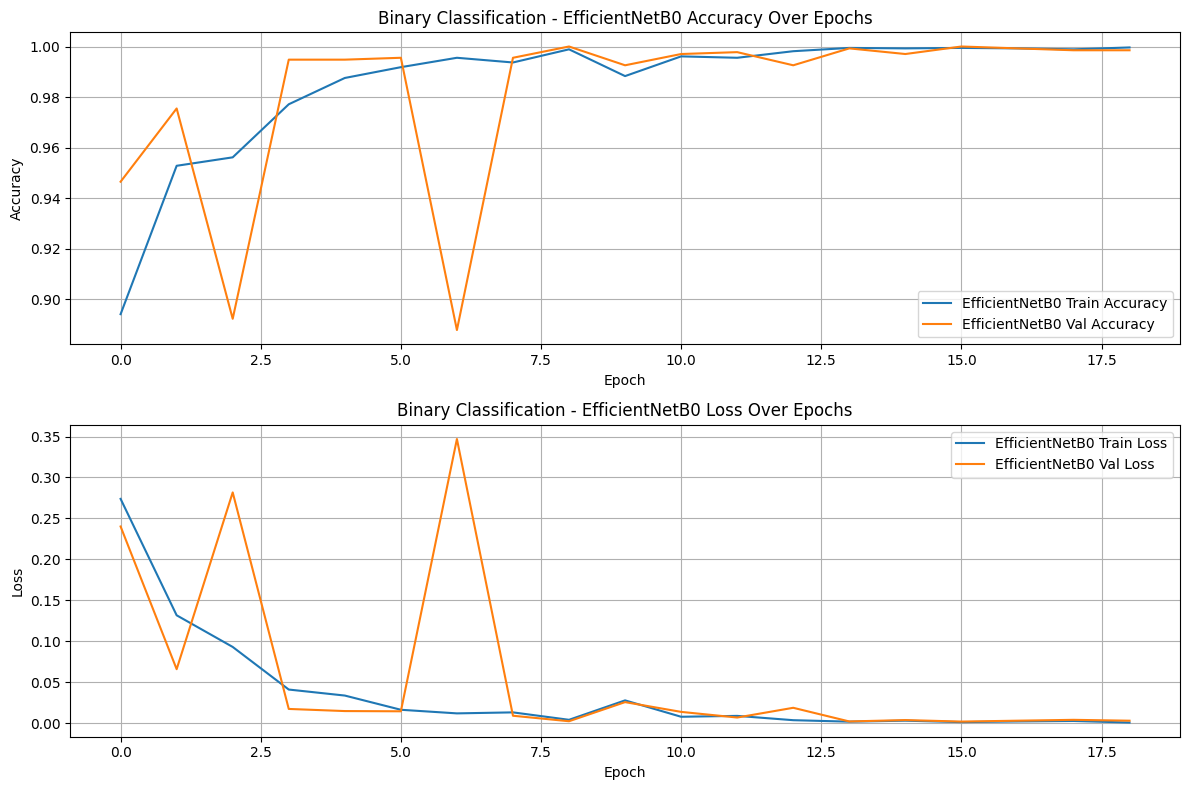

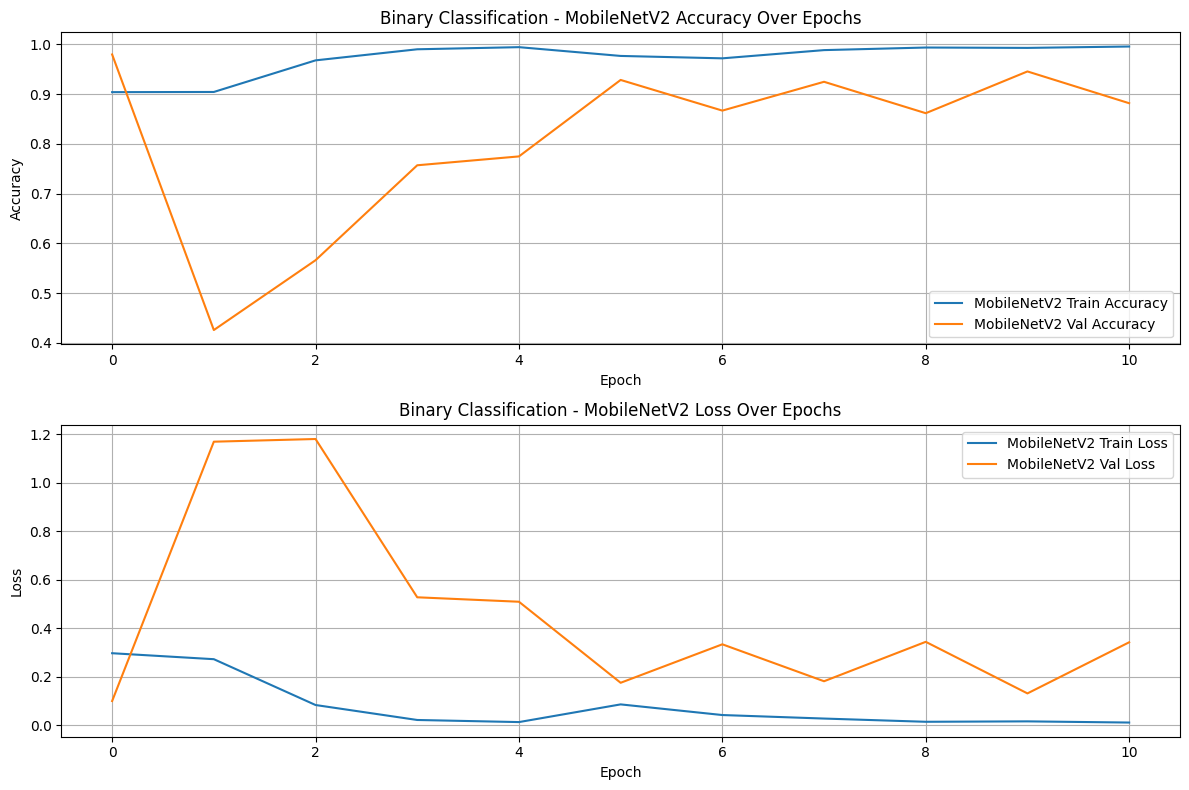

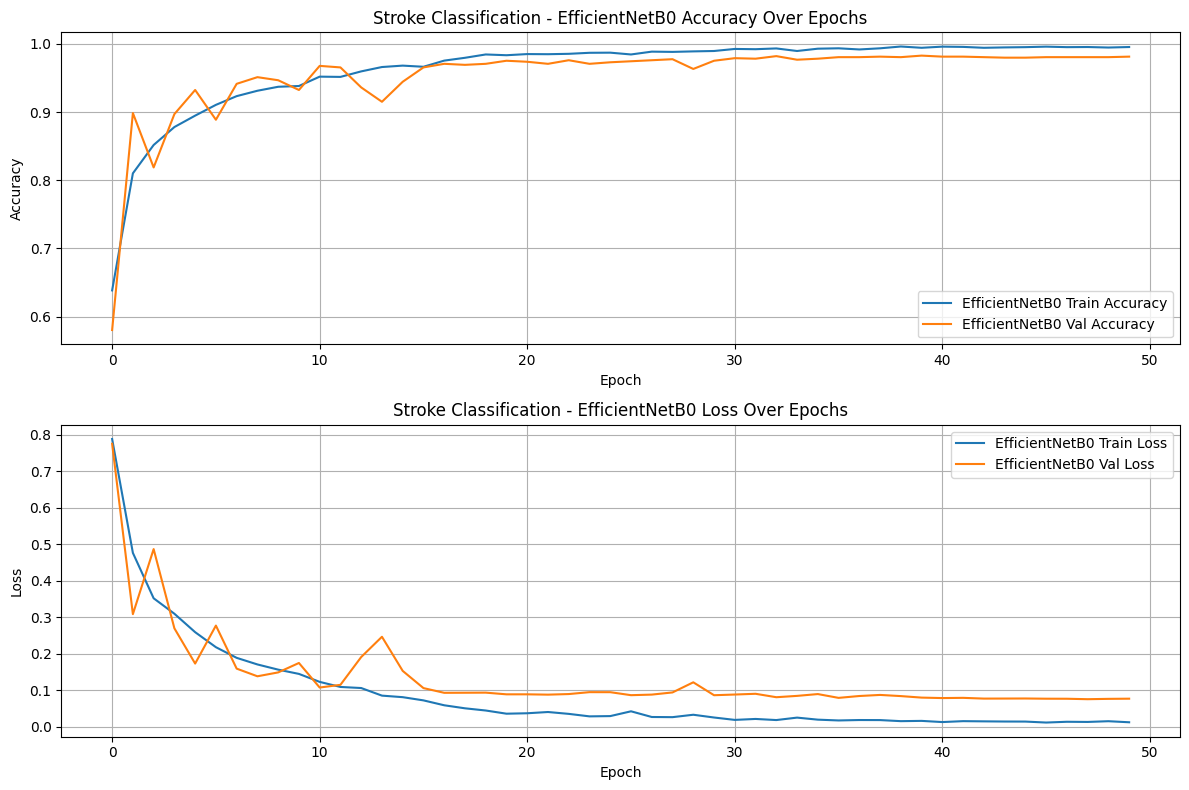

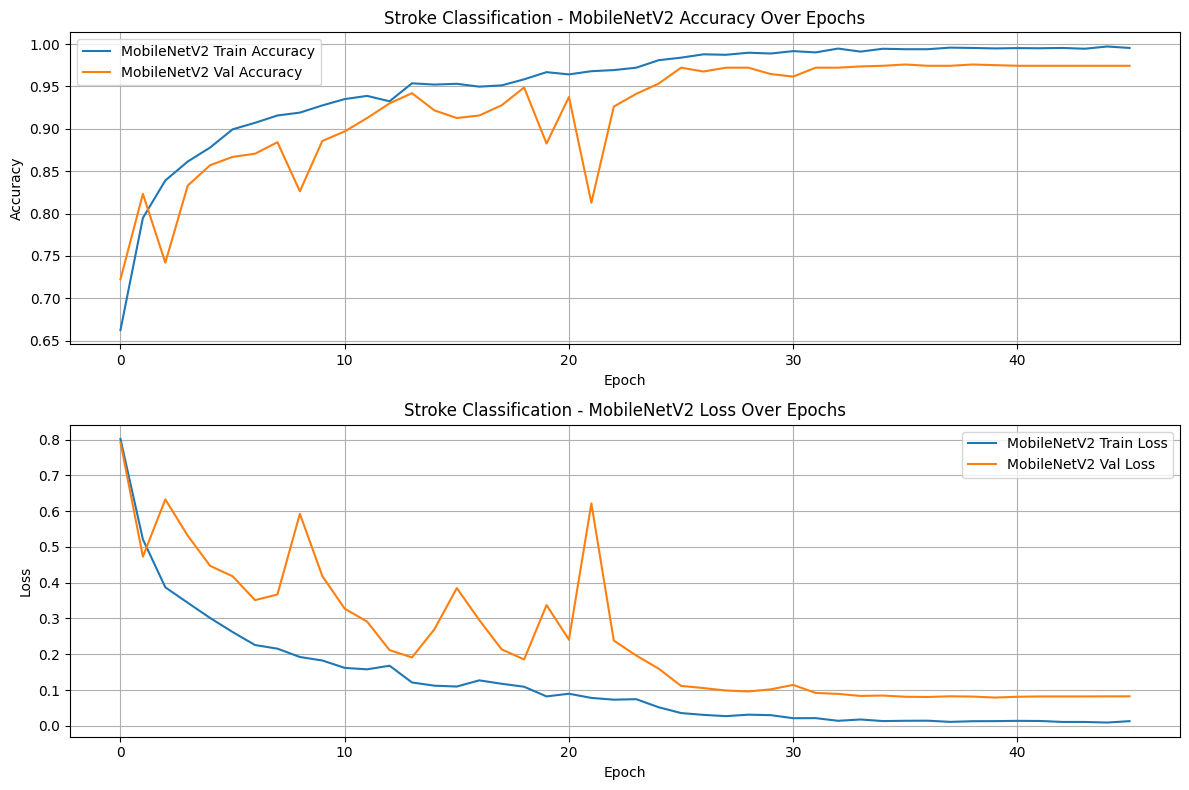


HIERARCHICAL BRAIN CT CLASSIFICATION SYSTEM COMPLETE!
✅ Binary Classifier saved: best_binary_classifier.keras
✅ Stroke Classifier saved: best_stroke_classifier.keras
✅ Best Binary Model: EfficientNetB0
✅ Best Stroke Model: EfficientNetB0
✅ Hierarchical pipeline ready for deployment!


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
import glob
from PIL import Image
import random
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenetv2_preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical

# --- Configuration ---
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 16
EPOCHS = 50
SEED = 42

# Hierarchical Classification Setup
BINARY_CLASSES = 2  # Stroke-related vs Others
STROKE_CLASSES = 3  # Normal, Hemorrhagic, Ischemic
BINARY_CLASS_NAMES = ['Others', 'Stroke-related']
STROKE_CLASS_NAMES = ['Normal', 'Hemorrhagic', 'Ischemia']

# Dataset paths
STROKE_DATASET_PATH = "/kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset"
OTHERS_DATASET_PATH = "/kaggle/input/others/Others"

# --- 1. Setup and Seeding ---
def set_seed(seed=42):
    """Set random seeds for reproducibility across all libraries."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seeds set to {seed} for reproducibility")

set_seed(SEED)

# --- 2. Dataset Loading and Analysis ---
def analyze_dataset(root_dir, dataset_name="Dataset"):
    """Analyzes dataset structure."""
    if not os.path.exists(root_dir):
        print(f"{dataset_name} root directory not found: {root_dir}")
        return {}
    
    structure = {}
    for item in os.listdir(root_dir):
        item_path = os.path.join(root_dir, item)
        if os.path.isdir(item_path):
            # Check for PNG subfolder first
            png_folder_path = os.path.join(item_path, "PNG")
            if os.path.exists(png_folder_path) and os.path.isdir(png_folder_path):
                files = glob.glob(os.path.join(png_folder_path, '*.png'))
                structure[item] = {'count': len(files), 'path': png_folder_path}
            else:
                # Check for direct PNG files
                files = glob.glob(os.path.join(item_path, '*.png'))
                if files:
                    structure[item] = {'count': len(files), 'path': item_path}
    
    # If no subdirectories, check for direct PNG files in root
    if not structure:
        files = glob.glob(os.path.join(root_dir, '*.png'))
        if files:
            structure['root'] = {'count': len(files), 'path': root_dir}

    print(f"\n{dataset_name} structure (counts of PNG files per class):")
    for class_name, info in structure.items():
        print(f"- {class_name}: {info['count']} images (from {info['path']})")
    return structure

# Analyze both datasets
print("=== ANALYZING DATASETS ===")
stroke_structure = analyze_dataset(STROKE_DATASET_PATH, "Stroke Dataset")
others_structure = analyze_dataset(OTHERS_DATASET_PATH, "Others Dataset")

def load_stroke_data(root_dir):
    """Loads stroke dataset (Normal, Hemorrhagic, Ischemic)."""
    image_paths = []
    labels = []
    class_map = {
        'Normal': 0,
        'Bleeding': 1,  # Maps to Hemorrhagic
        'Ischemia': 2
    }

    for class_folder_name, label_idx in class_map.items():
        # Try PNG subfolder first
        current_class_path = os.path.join(root_dir, class_folder_name, "PNG")
        if not os.path.exists(current_class_path) or not os.listdir(current_class_path):
            current_class_path = os.path.join(root_dir, class_folder_name)

        if os.path.exists(current_class_path):
            png_files = glob.glob(os.path.join(current_class_path, '*.png'))
            if not png_files:
                print(f"Warning: No PNG files found in {current_class_path} for class '{class_folder_name}'.")
                continue

            for img_path in png_files:
                image_paths.append(img_path)
                labels.append(label_idx)
            print(f"Loaded {len(png_files)} images for stroke class '{class_folder_name}' -> '{STROKE_CLASS_NAMES[label_idx]}'")
        else:
            print(f"Warning: Path {current_class_path} does not exist for class '{class_folder_name}'.")

    return image_paths, labels

def load_others_data(root_dir):
    """Loads others dataset."""
    image_paths = []
    
    # Check if there are subdirectories or direct files
    png_files = []
    
    # First try to find PNG files in subdirectories
    for item in os.listdir(root_dir):
        item_path = os.path.join(root_dir, item)
        if os.path.isdir(item_path):
            png_folder_path = os.path.join(item_path, "PNG")
            if os.path.exists(png_folder_path):
                png_files.extend(glob.glob(os.path.join(png_folder_path, '*.png')))
            else:
                png_files.extend(glob.glob(os.path.join(item_path, '*.png')))
    
    # If no files found in subdirectories, try root directory
    if not png_files:
        png_files = glob.glob(os.path.join(root_dir, '*.png'))
    
    image_paths = png_files
    labels = [0] * len(png_files)  # All others are labeled as 0 (for binary classification)
    
    print(f"Loaded {len(png_files)} images for 'Others' class")
    return image_paths, labels

# Load datasets
print("\n=== LOADING DATASETS ===")
stroke_paths, stroke_labels = load_stroke_data(STROKE_DATASET_PATH)
others_paths, others_labels = load_others_data(OTHERS_DATASET_PATH)

if not stroke_paths:
    print("CRITICAL ERROR: No stroke images were loaded.")
    sys.exit("Exiting due to no stroke data loaded.")

if not others_paths:
    print("CRITICAL ERROR: No others images were loaded.")
    sys.exit("Exiting due to no others data loaded.")

print(f"\nStroke dataset: {len(stroke_paths)} images")
print(f"Others dataset: {len(others_paths)} images")
print(f"Stroke class distribution: {pd.Series(stroke_labels).value_counts().sort_index().rename(index=dict(enumerate(STROKE_CLASS_NAMES)))}")

# --- 3. Prepare Binary Classification Data (Stroke vs Others) ---
print("\n=== PREPARING BINARY CLASSIFICATION DATA ===")

# Create binary dataset
binary_paths = stroke_paths + others_paths
binary_labels = [1] * len(stroke_paths) + [0] * len(others_paths)  # 1 for stroke-related, 0 for others

print(f"Binary classification dataset: {len(binary_paths)} images")
print(f"Binary class distribution: {pd.Series(binary_labels).value_counts().rename(index={0: 'Others', 1: 'Stroke-related'})}")

# Split binary data
binary_train_paths, binary_val_paths, binary_train_labels, binary_val_labels = train_test_split(
    binary_paths, binary_labels, test_size=0.2, random_state=SEED, stratify=binary_labels
)

# Split stroke data (for 3-class model)
stroke_train_paths, stroke_val_paths, stroke_train_labels, stroke_val_labels = train_test_split(
    stroke_paths, stroke_labels, test_size=0.2, random_state=SEED, stratify=stroke_labels
)

print(f"\nBinary training set: {len(binary_train_paths)} images")
print(f"Binary validation set: {len(binary_val_paths)} images")
print(f"Stroke training set: {len(stroke_train_paths)} images")
print(f"Stroke validation set: {len(stroke_val_paths)} images")

# Convert labels to categorical
binary_train_labels_cat = to_categorical(binary_train_labels, num_classes=BINARY_CLASSES)
binary_val_labels_cat = to_categorical(binary_val_labels, num_classes=BINARY_CLASSES)
stroke_train_labels_cat = to_categorical(stroke_train_labels, num_classes=STROKE_CLASSES)
stroke_val_labels_cat = to_categorical(stroke_val_labels, num_classes=STROKE_CLASSES)

# --- 4. Data Preprocessing Functions ---
def autocrop_brain_area(image_tensor, threshold_factor=0.15, pad_factor=0.1):
    """Automatically crops the brain area from a CT scan image using TensorFlow operations."""
    gray_image_float = tf.cast(tf.squeeze(tf.image.rgb_to_grayscale(image_tensor), axis=-1), tf.float32)
    
    min_val = tf.reduce_min(gray_image_float)
    max_val = tf.reduce_max(gray_image_float)
    threshold = min_val + (max_val - min_val) * tf.constant(threshold_factor, dtype=tf.float32)
    
    binary_image = tf.cast(gray_image_float > threshold, tf.float32)
    non_zero_indices = tf.where(binary_image > 0)
    
    if tf.shape(non_zero_indices)[0] == 0:
        return image_tensor
    
    min_y = tf.cast(tf.reduce_min(non_zero_indices[:, 0]), tf.int32)
    max_y = tf.cast(tf.reduce_max(non_zero_indices[:, 0]), tf.int32)
    min_x = tf.cast(tf.reduce_min(non_zero_indices[:, 1]), tf.int32)
    max_x = tf.cast(tf.reduce_max(non_zero_indices[:, 1]), tf.int32)
    
    height, width = tf.cast(tf.shape(image_tensor)[0], tf.int32), tf.cast(tf.shape(image_tensor)[1], tf.int32)
    
    pad_y = tf.cast(tf.cast((max_y - min_y), tf.float32) * pad_factor, tf.int32)
    pad_x = tf.cast(tf.cast((max_x - min_x), tf.float32) * pad_factor, tf.int32)
    
    y1 = tf.maximum(0, min_y - pad_y)
    x1 = tf.maximum(0, min_x - pad_x)
    y2 = tf.minimum(height, max_y + pad_y)
    x2 = tf.minimum(width, max_x + pad_x)
    
    if x2 <= x1 or y2 <= y1:
        return image_tensor
    
    cropped_image = image_tensor[y1:y2, x1:x2, :]
    return cropped_image

def parse_image(filepath, label, preprocess_fn):
    """Parse and preprocess image."""
    image = tf.io.read_file(filepath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.cast(image, tf.float32)
    image = autocrop_brain_area(image)
    image = tf.image.resize(image, [IMG_WIDTH, IMG_HEIGHT])
    image = preprocess_fn(image)
    return image, label

def augment_image(image, label):
    """Apply data augmentation."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    return image, label

def create_dataset(filepaths, labels, batch_size, preprocess_fn, is_training=True, shuffle=True):
    """Create TensorFlow dataset."""
    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(filepaths), seed=SEED)
    dataset = dataset.map(lambda fp, lbl: parse_image(fp, lbl, preprocess_fn), num_parallel_calls=tf.data.AUTOTUNE)
    if is_training:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# --- 5. Model Building ---
def build_model(base_model_name, num_classes, img_width, img_height, learning_rate=1e-4, model_type="binary"):
    """Build model for either binary or stroke classification."""
    input_shape = (img_width, img_height, 3)
    
    if base_model_name == 'EfficientNetB0':
        base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
        preprocess_fn = efficientnet_preprocess_input
    elif base_model_name == 'MobileNetV2':
        base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
        preprocess_fn = mobilenetv2_preprocess_input
    else:
        raise ValueError("Unsupported base_model_name")

    base_model.trainable = True

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=True)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    if model_type == "binary":
        metrics = [
            'accuracy',
            tf.keras.metrics.Precision(class_id=0, name='precision_others'),
            tf.keras.metrics.Recall(class_id=0, name='recall_others'),
            tf.keras.metrics.Precision(class_id=1, name='precision_stroke'),
            tf.keras.metrics.Recall(class_id=1, name='recall_stroke')
        ]
    else:  # stroke classification
        metrics = [
            'accuracy',
            tf.keras.metrics.Precision(class_id=0, name='precision_normal'),
            tf.keras.metrics.Recall(class_id=0, name='recall_normal'),
            tf.keras.metrics.Precision(class_id=1, name='precision_hemorrhagic'),
            tf.keras.metrics.Recall(class_id=1, name='recall_hemorrhagic'),
            tf.keras.metrics.Precision(class_id=2, name='precision_ischemic'),
            tf.keras.metrics.Recall(class_id=2, name='recall_ischemic')
        ]

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=metrics)
    return model, preprocess_fn

# --- 6. Training Function ---
def train_model(model_name, model_type, train_paths, train_labels, val_paths, val_labels, num_classes, class_names):
    """Train a model (either binary or stroke classifier)."""
    print(f"\n=== TRAINING {model_name.upper()} FOR {model_type.upper()} CLASSIFICATION ===")
    
    # Calculate class weights
    unique_labels = np.unique([np.argmax(label) for label in train_labels])
    train_labels_int = [np.argmax(label) for label in train_labels]
    class_weights_calculated = class_weight.compute_class_weight(
        'balanced',
        classes=unique_labels,
        y=train_labels_int
    )
    class_weights_dict = dict(zip(unique_labels, class_weights_calculated))
    print(f"Class weights: {class_weights_dict}")
    
    # Build model
    model, preprocess_fn = build_model(model_name, num_classes, IMG_WIDTH, IMG_HEIGHT, model_type=model_type)
    
    # Create datasets
    train_ds = create_dataset(train_paths, train_labels, BATCH_SIZE, preprocess_fn, is_training=True)
    val_ds = create_dataset(val_paths, val_labels, BATCH_SIZE, preprocess_fn, is_training=False, shuffle=False)
    
    # Callbacks
    model_checkpoint_path = f'best_{model_name}_{model_type}_temp.keras'
    callbacks = [
        ModelCheckpoint(
            filepath=model_checkpoint_path,
            save_best_only=True,
            monitor='val_accuracy',
            mode='max',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.2,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True,
            verbose=1,
        )
    ]
    
    # Train model
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=callbacks,
        class_weight=class_weights_dict
    )
    
    # Load best weights
    if os.path.exists(model_checkpoint_path):
        model.load_weights(model_checkpoint_path)
    
    # Evaluate
    val_loss, val_accuracy, *val_metrics = model.evaluate(val_ds, verbose=0)
    print(f"{model_name} {model_type} - Validation Accuracy: {val_accuracy:.4f}")
    
    # Predictions for confusion matrix
    y_pred_probs = model.predict(val_ds)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = [np.argmax(label) for label in val_labels]
    
    print(f"\nClassification Report for {model_name} {model_type}:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=class_names, zero_division=0))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name} {model_type.title()} Classification')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    return model, history, val_accuracy, preprocess_fn

# --- 7. Train Both Models ---
models_to_train = ['EfficientNetB0', 'MobileNetV2']

# Storage for trained models
binary_models = {}
stroke_models = {}
binary_histories = {}
stroke_histories = {}
binary_performances = {}
stroke_performances = {}
model_preprocess_fns = {}

# Train binary classifiers
print("\n" + "="*50)
print("TRAINING BINARY CLASSIFIERS (STROKE vs OTHERS)")
print("="*50)

for model_name in models_to_train:
    model, history, accuracy, preprocess_fn = train_model(
        model_name, "binary", 
        binary_train_paths, binary_train_labels_cat,
        binary_val_paths, binary_val_labels_cat,
        BINARY_CLASSES, BINARY_CLASS_NAMES
    )
    binary_models[model_name] = model
    binary_histories[model_name] = history
    binary_performances[model_name] = accuracy
    model_preprocess_fns[f"{model_name}_binary"] = preprocess_fn

# Train stroke classifiers
print("\n" + "="*50)
print("TRAINING STROKE CLASSIFIERS (NORMAL vs HEMORRHAGIC vs ISCHEMIC)")
print("="*50)

for model_name in models_to_train:
    model, history, accuracy, preprocess_fn = train_model(
        model_name, "stroke",
        stroke_train_paths, stroke_train_labels_cat,
        stroke_val_paths, stroke_val_labels_cat,
        STROKE_CLASSES, STROKE_CLASS_NAMES
    )
    stroke_models[model_name] = model
    stroke_histories[model_name] = history
    stroke_performances[model_name] = accuracy
    model_preprocess_fns[f"{model_name}_stroke"] = preprocess_fn

# --- 8. Select Best Models ---
print("\n" + "="*50)
print("MODEL SELECTION")
print("="*50)

best_binary_model = max(binary_performances, key=binary_performances.get)
best_stroke_model = max(stroke_performances, key=stroke_performances.get)

print(f"Best Binary Classifier: {best_binary_model} (Accuracy: {binary_performances[best_binary_model]:.4f})")
print(f"Best Stroke Classifier: {best_stroke_model} (Accuracy: {stroke_performances[best_stroke_model]:.4f})")

# Save best models
binary_models[best_binary_model].save('best_binary_classifier.keras')
stroke_models[best_stroke_model].save('best_stroke_classifier.keras')
print(f"\nSaved best binary classifier: best_binary_classifier.keras")
print(f"Saved best stroke classifier: best_stroke_classifier.keras")

# --- 9. Hierarchical Classification Pipeline ---
class HierarchicalClassifier:
    def __init__(self, binary_model, stroke_model, binary_preprocess_fn, stroke_preprocess_fn):
        self.binary_model = binary_model
        self.stroke_model = stroke_model
        self.binary_preprocess_fn = binary_preprocess_fn
        self.stroke_preprocess_fn = stroke_preprocess_fn
        
    def predict(self, image_paths, batch_size=BATCH_SIZE):
        """Predict using hierarchical approach."""
        # Step 1: Binary classification
        binary_ds = create_dataset(image_paths, [0] * len(image_paths), batch_size, 
                                 self.binary_preprocess_fn, is_training=False, shuffle=False)
        
        binary_preds = self.binary_model.predict(binary_ds)
        binary_classes = np.argmax(binary_preds, axis=1)
        
        final_predictions = []
        final_class_names = []
        
        # Step 2: For stroke-related images, use stroke classifier
        stroke_indices = np.where(binary_classes == 1)[0]  # Stroke-related class is 1
        
        if len(stroke_indices) > 0:
            stroke_paths = [image_paths[i] for i in stroke_indices]
            stroke_ds = create_dataset(stroke_paths, [0] * len(stroke_paths), batch_size,
                                     self.stroke_preprocess_fn, is_training=False, shuffle=False)
            stroke_preds = self.stroke_model.predict(stroke_ds)
            stroke_classes = np.argmax(stroke_preds, axis=1)
        
        # Combine results
        for i, binary_class in enumerate(binary_classes):
            if binary_class == 0:  # Others
                final_predictions.append(3)  # Use 3 for "Others" in final classification
                final_class_names.append("Others")
            else:  # Stroke-related
                stroke_idx = np.where(stroke_indices == i)[0][0]
                stroke_class = stroke_classes[stroke_idx]
                final_predictions.append(stroke_class)
                final_class_names.append(STROKE_CLASS_NAMES[stroke_class])
        
        return final_predictions, final_class_names, binary_preds, stroke_preds if len(stroke_indices) > 0 else None

# Create hierarchical classifier
hierarchical_classifier = HierarchicalClassifier(
    binary_models[best_binary_model],
    stroke_models[best_stroke_model],
    model_preprocess_fns[f"{best_binary_model}_binary"],
    model_preprocess_fns[f"{best_stroke_model}_stroke"]
)

# --- 10. Test Hierarchical System ---
print("\n" + "="*50)
print("TESTING HIERARCHICAL CLASSIFICATION SYSTEM")
print("="*50)

# Create test set from validation data
test_paths = binary_val_paths[:50]  # Test on first 50 validation samples
test_true_binary = binary_val_labels[:50]

predictions, class_names, binary_probs, stroke_probs = hierarchical_classifier.predict(test_paths)

print("Sample Hierarchical Predictions:")
for i in range(min(10, len(predictions))):
    true_binary = np.argmax(test_true_binary[i])
    true_binary_name = BINARY_CLASS_NAMES[true_binary]
    print(f"Image {i+1}: True={true_binary_name}, Predicted={class_names[i]}")

print(f"\nHierarchical system tested on {len(test_paths)} images")
print("System is ready for deployment!")

# --- 11. Plot Training Histories ---
def plot_training_history(histories, title_prefix):
    """Plot training histories."""
    for model_name, history in histories.items():
        plt.figure(figsize=(12, 8))
        
        plt.subplot(2, 1, 1)
        plt.plot(history.history['accuracy'], label=f'{model_name} Train Accuracy')
        plt.plot(history.history['val_accuracy'], label=f'{model_name} Val Accuracy')
        plt.title(f'{title_prefix} - {model_name} Accuracy Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

        plt.subplot(2, 1, 2)
        plt.plot(history.history['loss'], label=f'{model_name} Train Loss')
        plt.plot(history.history['val_loss'], label=f'{model_name} Val Loss')
        plt.title(f'{title_prefix} - {model_name} Loss Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()

plot_training_history(binary_histories, "Binary Classification")
plot_training_history(stroke_histories, "Stroke Classification")

print("\n" + "="*50)
print("HIERARCHICAL BRAIN CT CLASSIFICATION SYSTEM COMPLETE!")
print("="*50)
print(f"✅ Binary Classifier saved: best_binary_classifier.keras")
print(f"✅ Stroke Classifier saved: best_stroke_classifier.keras")
print(f"✅ Best Binary Model: {best_binary_model}")
print(f"✅ Best Stroke Model: {best_stroke_model}")
print("✅ Hierarchical pipeline ready for deployment!")